<div style="text-align: center">
    <h2><font size=6>MODELO - MobileNetV2 - FINETUNING</font></h2>
</d>
</div>

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [14]:
train_dir = "dataset_final/train"
val_dir = "dataset_final/validation"
test_dir = "dataset_final/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [15]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4455 images belonging to 6 classes.
Found 952 images belonging to 6 classes.
Found 959 images belonging to 6 classes.


In [16]:
print(train_generator.class_indices)

{'AgeDegeneration': 0, 'Myopia': 1, 'cataract': 2, 'diabetic_retinopathy': 3, 'glaucoma': 4, 'healthy': 5}


In [17]:
num_classes = train_generator.num_classes
print("Número de clases:", num_classes)

Número de clases: 6


**Cargar modelo MobileNetV2**

In [15]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [16]:
for layer in base_model.layers:
    layer.trainable = False

In [17]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30
)

Epoch 1/30


C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


140/140 ━━━━━━━━━━━━━━━━━━━━ 125s 840ms/step - accuracy: 0.3504 - loss: 1.7324 - val_accuracy: 0.6471 - val_loss: 1.0137
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 117s 822ms/step - accuracy: 0.6081 - loss: 1.0656 - val_accuracy: 0.6912 - val_loss: 0.8967
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 819ms/step - accuracy: 0.6319 - loss: 0.9709 - val_accuracy: 0.6870 - val_loss: 0.8616
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 821ms/step - accuracy: 0.6822 - loss: 0.8839 - val_accuracy: 0.7006 - val_loss: 0.8316
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 817ms/step - accuracy: 0.7040 - loss: 0.8169 - val_accuracy: 0.7153 - val_loss: 0.7999
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 818ms/step - accuracy: 0.7106 - loss: 0.8093 - val_accuracy: 0.7153 - val_loss: 0.7783
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 816ms/step - accuracy: 0.7091 - loss: 0.7924 - val_accuracy: 0.7206 - val_loss: 0.7747
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 116s 817ms/step - accuracy: 0.7309 - loss: 0.75

In [21]:
loss, acc = model.evaluate(test_generator)

print("Loss en test:", loss)
print("Accuracy en test:", acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 580ms/step - accuracy: 0.7688 - loss: 0.6810
Loss en test: 0.6329001784324646
Accuracy en test: 0.7799791693687439


In [22]:
model.save("modelo_mobilenetv2_base.h5")

In [23]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [24]:
for layer in model.layers:
    print(layer.name, layer.trainable)

input_layer_2 False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_d

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 146s 955ms/step - accuracy: 0.5384 - loss: 1.4647 - val_accuracy: 0.7143 - val_loss: 0.7893
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 938ms/step - accuracy: 0.6990 - loss: 0.8470 - val_accuracy: 0.7206 - val_loss: 0.7852
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 936ms/step - accuracy: 0.7345 - loss: 0.7620 - val_accuracy: 0.7248 - val_loss: 0.7874
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 936ms/step - accuracy: 0.7556 - loss: 0.6974 - val_accuracy: 0.7321 - val_loss: 0.7778
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 937ms/step - accuracy: 0.7635 - loss: 0.6552 - val_accuracy: 0.7332 - val_loss: 0.7732
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 941ms/step - accuracy: 0.7672 - loss: 0.6499 - val_accuracy: 0.7363 - val_loss: 0.7695
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 134s 943ms/step - accuracy: 0.7996 - loss: 0.5699 - val_accuracy: 0.7405 - val_loss: 0.7459
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 133s 936ms/step - accuracy: 0.7927 -

In [27]:
loss, acc = model.evaluate(test_generator)

print("Loss final:", loss)
print("Accuracy final:", acc)

30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 577ms/step - accuracy: 0.7894 - loss: 0.7292
Loss final: 0.578824520111084
Accuracy final: 0.821689248085022


In [28]:
model.save("modelo_mobilenetv2_finetuned.h5")

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

Matplotlib is building the font cache; this may take a moment.


In [11]:
model = load_model("modelo_mobilenetv2_finetuned.h5")

In [18]:
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(test_generator.class_indices)

30/30 ━━━━━━━━━━━━━━━━━━━━ 26s 789ms/step
{'AgeDegeneration': 0, 'Myopia': 1, 'cataract': 2, 'diabetic_retinopathy': 3, 'glaucoma': 4, 'healthy': 5}


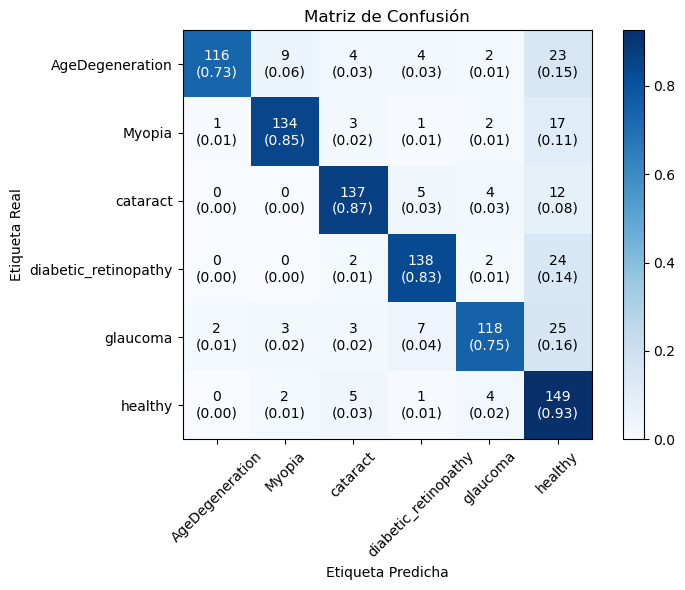

In [19]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_normalized, interpolation='nearest', cmap=plt.cm.Blues)

plt.title("Matriz de Confusión")
plt.colorbar()

tick_marks = np.arange(len(class_labels))

plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

thresh = conf_matrix_normalized.max() / 2.

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):

        absolute_value = conf_matrix[i, j]
        percentage_value = conf_matrix_normalized[i, j]

        plt.text(j, i,
                 f"{absolute_value}\n({percentage_value:.2f})",
                 horizontalalignment="center",
                 verticalalignment="center",
                 color="white" if percentage_value > thresh else "black")

plt.ylabel("Etiqueta Real")
plt.xlabel("Etiqueta Predicha")

plt.tight_layout()
plt.show()

In [20]:
print("Reporte de Clasificación:")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

Reporte de Clasificación:
                      precision    recall  f1-score   support

     AgeDegeneration       0.97      0.73      0.84       158
              Myopia       0.91      0.85      0.88       158
            cataract       0.89      0.87      0.88       158
diabetic_retinopathy       0.88      0.83      0.86       166
            glaucoma       0.89      0.75      0.81       158
             healthy       0.60      0.93      0.73       161

            accuracy                           0.83       959
           macro avg       0.86      0.83      0.83       959
        weighted avg       0.86      0.83      0.83       959



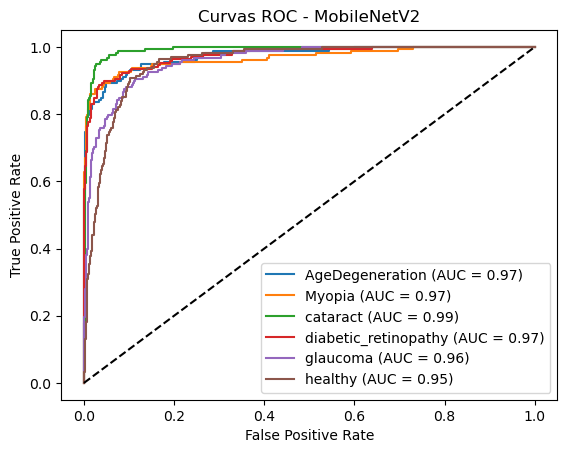

In [39]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=range(num_classes))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_labels[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - MobileNetV2")
plt.legend()
plt.show()